### Librerias

In [1]:
# Importamos las librerías: datos, modelos de embeddings (gensim y sentence-transformers), métricas y gráficos
import pandas as pd
import numpy as np
from pathlib import Path
import shutil
from gensim.models import KeyedVectors, Word2Vec
import gdown
import ast
from sentence_transformers import SentenceTransformer, util
from prettytable import PrettyTable
import unicodedata
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity, paired_cosine_distances
import matplotlib.pyplot as plt
import re
import random
from itertools import combinations, product
import zlib
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

C:\Users\aldys\Desktop\NLP\NLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Creamos una copia del CSV original para no modificarlo

def copiar_csv(ruta_csv_original, ruta_csv_copia):
    """Copia un archivo CSV a una nueva ubicación (sobrescribe si ya existe)."""
    Path(ruta_csv_copia).parent.mkdir(parents=True, exist_ok=True)
    shutil.copy(ruta_csv_original, ruta_csv_copia)
    print(f"Archivo copiado: {ruta_csv_original} -> {ruta_csv_copia}")


# Copiamos el CSV de la Práctica 1 a esta carpeta; de acá en adelante se trabaja sobre la copia
copiar_csv("../Practica1/data/libros.csv", "data/libros_copia.csv")

Archivo copiado: ../Practica1/data/libros.csv -> data/libros_copia.csv


## TF-IDF

In [3]:
# Definimos TF-IDF y lo aplicamos al CSV copia (sin limpiar) como punto de partida
def TFIDF(ruta_csv, columna="sinopsis"):
    """Lee un CSV y devuelve el TfidfVectorizer ajustado y la matriz TF-IDF."""
    # Leemos el CSV
    df = pd.read_csv(ruta_csv, encoding="utf-8-sig")
    # Nos quedamos con las sinopsis no vacías como lista de textos
    corpus = df[columna].dropna().astype(str).tolist()
    # Ajustamos TF-IDF sobre todo el corpus
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(corpus)
    return vectorizer, X

# Obtenemos el vectorizador y la matriz documento-término del CSV sin limpiar
vectorizer, X = TFIDF("data/libros_copia.csv")


In [4]:
# Estadísticas de la matriz TF-IDF

def resumen_tfidf(X, vectorizer, top=10):
    palabras = vectorizer.get_feature_names_out()
    idf = vectorizer.idf_
    n_docs, n_terminos = X.shape

    print("=== Dimensiones ===")
    print(f"Documentos (filas):         {n_docs}")
    print(f"Términos únicos (columnas): {n_terminos}")

    print(f"\n=== Top {top} palabras más comunes (menor IDF) ===")
    for i in np.argsort(idf)[:top]:
        print(f"{palabras[i]:<20} IDF = {idf[i]:.4f}")


# Mostramos las estadísticas: se espera que las stopwords tengan el menor IDF
resumen_tfidf(X, vectorizer)

=== Dimensiones ===
Documentos (filas):         400
Términos únicos (columnas): 10987

=== Top 10 palabras más comunes (menor IDF) ===
de                   IDF = 1.0125
la                   IDF = 1.0512
en                   IDF = 1.0538
el                   IDF = 1.0886
que                  IDF = 1.1079
un                   IDF = 1.1918
una                  IDF = 1.2101
los                  IDF = 1.2288
del                  IDF = 1.3002
se                   IDF = 1.3070


## Limpieza del dataset

In [5]:
# Conjunto de stopwords en español
STOPWORDS_ES = {
    # artículos, preposiciones, conjunciones
    "a", "al", "ante", "bajo", "cabe", "con", "contra", "de", "del", "desde",
    "durante", "e", "el", "en", "entre", "hacia", "hasta", "la", "las", "lo",
    "los", "mediante", "para", "por", "segun", "sin", "so", "sobre", "tras",
    "un", "una", "unas", "uno", "unos", "y", "o", "u", "ni", "que", "pero",
    "sino", "aunque", "porque", "pues", "si", "como", "cuando", "donde",
    "mientras", "cual", "cuales", "quien", "quienes", "cuyo", "cuya", "cuyos",
    "cuyas", "cuanto", "cuanta", "cuantos", "cuantas", "cuan",

    # pronombres personales y posesivos
    "yo", "me", "mi", "mis", "conmigo", "tu", "tus", "te", "ti", "contigo",
    "vos", "usted", "ustedes", "el", "ella", "ello", "ellos", "ellas", "se",
    "si", "consigo", "le", "les", "nos", "nosotros", "nosotras", "vosotros",
    "vosotras", "os", "mio", "mia", "mios", "mias", "tuyo", "tuya", "tuyos",
    "tuyas", "suyo", "suya", "suyos", "suyas", "su", "sus", "nuestro",
    "nuestra", "nuestros", "nuestras", "vuestro", "vuestra", "vuestros",
    "vuestras",

    # demostrativos
    "este", "esta", "esto", "estos", "estas", "ese", "esa", "eso", "esos",
    "esas", "aquel", "aquella", "aquello", "aquellos", "aquellas", "aqui",
    "ahi", "alli", "alla", "aca", "aqui",

    # indefinidos y cuantificadores
    "algo", "alguien", "alguno", "alguna", "algunos", "algunas", "ninguno",
    "ninguna", "ningunos", "ningunas", "nadie", "nada", "otro", "otra",
    "otros", "otras", "mismo", "misma", "mismos", "mismas", "todo", "toda",
    "todos", "todas", "mucho", "mucha", "muchos", "muchas", "poco", "poca",
    "pocos", "pocas", "tanto", "tanta", "tantos", "tantas", "cada", "cualquier",
    "cualquiera", "varios", "varias", "demas", "bastante", "bastantes",
    "tal", "tales", "ambos", "ambas", "sendos", "sendas", "ciertos", "ciertas",
    "cierto", "cierta", "dos", "tres",

    # adverbios y locuciones frecuentes
    "no", "mas", "menos", "muy", "tan", "tambien", "tampoco", "ya", "aun",
    "todavia", "ahora", "antes", "despues", "luego", "entonces", "siempre",
    "nunca", "jamas", "asi", "bien", "mal", "mejor", "peor", "casi", "solo",
    "solamente", "apenas", "quiza", "quizas", "acaso", "tarde", "temprano",
    "hoy", "ayer", "manana", "cerca", "lejos", "encima", "debajo", "dentro",
    "fuera", "delante", "detras", "arriba", "abajo", "adelante", "atras",
    "alrededor", "junto", "ademas", "incluso", "pronto", "mientras", "cuando",
    "como", "donde", "adonde", "cuando", "cuanto", "demasiado", "demasiada",
    "demasiados", "demasiadas",

    # ser
    "ser", "soy", "eres", "es", "somos", "sois", "son", "era", "eras", "eramos",
    "erais", "eran", "fui", "fuiste", "fue", "fuimos", "fuisteis", "fueron",
    "sere", "seras", "sera", "seremos", "sereis", "seran", "seria", "serias",
    "seriamos", "seriais", "serian", "sea", "seas", "seamos", "seais", "sean",
    "fuera", "fueras", "fueramos", "fuerais", "fueran", "fuese", "fueses",
    "fuesemos", "fueseis", "fuesen", "siendo", "sido", "se",

    # estar
    "estar", "estoy", "estas", "esta", "estamos", "estais", "estan", "estaba",
    "estabas", "estabamos", "estabais", "estaban", "estuve", "estuviste",
    "estuvo", "estuvimos", "estuvisteis", "estuvieron", "estare", "estaras",
    "estara", "estaremos", "estareis", "estaran", "estaria", "estarias",
    "estariamos", "estariais", "estarian", "este", "estes", "estemos",
    "esteis", "esten", "estuviera", "estuvieras", "estuvieramos", "estuvierais",
    "estuvieran", "estuviese", "estuvieses", "estuviesemos", "estuvieseis",
    "estuviesen", "estando", "estado", "estada", "estados", "estadas",

    # haber
    "haber", "he", "has", "ha", "hemos", "habeis", "han", "hay", "habia",
    "habias", "habiamos", "habiais", "habian", "hube", "hubiste", "hubo",
    "hubimos", "hubisteis", "hubieron", "habre", "habras", "habra", "habremos",
    "habreis", "habran", "habria", "habrias", "habriamos", "habriais",
    "habrian", "haya", "hayas", "hayamos", "hayais", "hayan", "hubiera",
    "hubieras", "hubieramos", "hubierais", "hubieran", "hubiese", "hubieses",
    "hubiesemos", "hubieseis", "hubiesen", "habiendo", "habido", "habida",
    "habidos", "habidas",

    # tener
    "tener", "tengo", "tienes", "tiene", "tenemos", "teneis", "tienen",
    "tenia", "tenias", "teniamos", "teniais", "tenian", "tuve", "tuviste",
    "tuvo", "tuvimos", "tuvisteis", "tuvieron", "tendre", "tendras", "tendra",
    "tendremos", "tendreis", "tendran", "tendria", "tendrias", "tendriamos",
    "tendriais", "tendrian", "tenga", "tengas", "tengamos", "tengais",
    "tengan", "tuviera", "tuvieras", "tuvieramos", "tuvierais", "tuvieran",
    "tuviese", "tuvieses", "tuviesemos", "tuvieseis", "tuviesen", "teniendo",
    "tenido", "tenida", "tenidos", "tenidas",

    # ir, hacer, poder, decir, ver, dar (formas muy frecuentes)
    "ir", "voy", "vas", "va", "vamos", "vais", "van", "iba", "ibas", "ibamos",
    "ibais", "iban", "vaya", "vayas", "vayamos", "vayais", "vayan", "yendo",
    "ido", "hacer", "hago", "haces", "hace", "hacemos", "haceis", "hacen",
    "hacia", "hice", "hizo", "hicieron", "hara", "haran", "haga", "hagan",
    "haciendo", "hecho", "poder", "puedo", "puedes", "puede", "podemos",
    "podeis", "pueden", "podia", "podian", "pudo", "pudieron", "podria",
    "podrian", "pueda", "puedan", "decir", "digo", "dice", "dicen", "dijo",
    "dijeron", "ver", "veo", "ve", "vemos", "ven", "vio", "vieron", "dar",
    "doy", "da", "damos", "dan", "dio", "dieron"}

# Columnas del CSV que contienen texto y deben ser limpiadas.
COLUMNAS_DE_TEXTO = ["titulo", "serie", "sinopsis"]

# Rutas (relativas a la carpeta del notebook, igual que la copia del CSV)
RUTA_CSV_ORIGINAL = Path("data/libros_copia.csv")
RUTA_CSV_LIMPIO = Path("data/libros_limpios.csv")
RUTA_MODELO = Path("modelos")


# FUNCIONES DE LIMPIEZA DE TEXTO

def minusculas(texto):
    """
    Convierte un texto a minúsculas.
    Args: texto (str): Texto a convertir.
    Returns: str: Texto en minúsculas.
    """
    return texto.lower()


def acentos_dieresis_virgulilla(texto):
    """
    Elimina los acentos de un texto, dieresis en la letra 'u' y virgulilla en la letra 'ñ'.
    Args: texto (str): Texto a procesar.
    Returns: str: Texto sin acentos.
    """
    # Se normaliza caracter por caracter: si se aplicara NFD al texto completo, la 'ñ' se
    # descompondria en 'n' + virgulilla y se perderia al quitar las marcas.
    resultado = []
    for c in texto:
        if c in 'ñÑ':
            resultado.append(c)
        else:
            descompuesto = unicodedata.normalize('NFD', c)
            resultado.extend(d for d in descompuesto if unicodedata.category(d) != 'Mn')
    return ''.join(resultado)


def quitar_puntuacion(texto):
    """
    Elimina la puntuación de un texto (y otros signos)
    Args: texto (str): Texto a procesar.
    Returns: str: Texto sin puntuación.
    """
    return ''.join(c for c in texto if c.isalnum() or c.isspace())


def quitar_stopwords(texto, stopwords_set):
    """
    Elimina las stopwords de un texto.
    Args: texto (str): Texto a procesar.
        stopwords_set (set): Conjunto de stopwords a eliminar.
    Returns: str: Texto sin stopwords.
    """
    return ' '.join(palabra for palabra in texto.split() if palabra not in stopwords_set)


# Las stopwords se normalizan con el mismo proceso que el texto (minusculas y sin acentos);
# si no, palabras como "más" o "también" nunca coincidirian con el texto ya sin acentos.
STOPWORDS_ES = {acentos_dieresis_virgulilla(minusculas(palabra)) for palabra in STOPWORDS_ES}


# Funcion que aplica todas las funciones de limpieza al texto

def limpiar_texto(texto):
    """Aplica todas las funciones de procesamiento de texto en orden."""
    texto = minusculas(texto)
    texto = acentos_dieresis_virgulilla(texto)
    texto = quitar_puntuacion(texto)
    texto = quitar_stopwords(texto, STOPWORDS_ES)
    return texto


# Funcion que aplica todas las funciones de limpieza al csv (copia) 

def limpiar_libros():
    """Copia el CSV original, limpia sus columnas textuales y crea otro CSV."""
    if not RUTA_CSV_ORIGINAL.exists():
        raise FileNotFoundError(
            f"No se encontró el CSV original: {RUTA_CSV_ORIGINAL}"
        )

    # Leemos la copia del CSV sin convertir los vacíos en NaN
    libros = pd.read_csv(RUTA_CSV_ORIGINAL, keep_default_na=False)
    # Verificamos que existan todas las columnas de texto a limpiar
    columnas_faltantes = [
        columna for columna in COLUMNAS_DE_TEXTO if columna not in libros.columns
    ]
    if columnas_faltantes:
        raise ValueError(f"Faltan columnas de texto: {columnas_faltantes}")

    # Limpiamos cada columna de texto
    for columna in COLUMNAS_DE_TEXTO:
        libros[columna] = libros[columna].map(limpiar_texto)

    # Convertimos autores y géneros de texto a listas y limpiamos cada elemento
    libros["autores"] = libros["autores"].apply(ast.literal_eval)
    libros["generos"] = libros["generos"].apply(ast.literal_eval)
    libros["autores"] = libros["autores"].apply(lambda autores: list(map(limpiar_texto, autores)))
    libros["generos"] = libros["generos"].apply(lambda generos: list(map(limpiar_texto, generos)))

    # Guardamos el resultado en el CSV limpio
    libros.to_csv(RUTA_CSV_LIMPIO, index=False, encoding="utf-8")
    print(f"CSV limpio creado: {RUTA_CSV_LIMPIO}")
    print(f"Registros procesados: {len(libros)}")

In [6]:
# Aplicamos la limpieza al CSV

limpiar_libros()

CSV limpio creado: data\libros_limpios.csv
Registros procesados: 400


Como ya aplicamos TF-IDF en el csv sin limpiar y efectivamente las stopwords fueron las más frecuentes, lo aplicaremos nuevamente para comparar los resultados.

In [7]:
# Repetimos TF-IDF sobre el CSV limpio para comparar contra el resultado anterior
vectorizer_limpio, X_limpio = TFIDF(RUTA_CSV_LIMPIO)
resumen_tfidf(X_limpio, vectorizer_limpio)

=== Dimensiones ===
Documentos (filas):         400
Términos únicos (columnas): 10569

=== Top 10 palabras más comunes (menor IDF) ===
mundo                IDF = 2.2318
vida                 IDF = 2.3211
novela               IDF = 2.3496
historia             IDF = 2.3690
aventuras            IDF = 2.4507
años                 IDF = 2.7599
vez                  IDF = 2.7893
aventura             IDF = 2.8196
guerra               IDF = 2.8996
joven                IDF = 2.9164


## SBW

In [8]:
# Datos y funciones para obtener el modelo SBW, descargándolo si hace falta
url = "https://drive.google.com/uc?id=1V8hNcnGEyrz0c_dA-v0_5sg31bNgy75r"
RUTA_SBW = RUTA_MODELO / "SBW-vectors-300-min5.bin.gz"

def modelo_valido(ruta_modelo):
    """
    Indica si el archivo existe y es un gzip real (no un puntero de Git LFS ni una descarga corrupta).
    """
    ruta_modelo = Path(ruta_modelo)
    if not ruta_modelo.exists():
        return False
    # Todo gzip real empieza con los bytes 0x1F 0x8B
    with open(ruta_modelo, "rb") as f:
        return f.read(2) == bytes([0x1F, 0x8B])

def SBW_modelo(ruta_modelo=RUTA_SBW):
    """
    Carga el modelo SBW (Spanish Billion Words) desde la ruta especificada.
    Si el modelo no existe, lo descarga primero desde Google Drive.
    Returns:
        KeyedVectors: El modelo SBW cargado.
    """
    # Descargamos el modelo solo si falta o está corrupto
    if not modelo_valido(ruta_modelo):
        Path(ruta_modelo).parent.mkdir(parents=True, exist_ok=True)
        gdown.download(url, str(ruta_modelo), quiet=False)
        if not modelo_valido(ruta_modelo):
            raise RuntimeError(f"La descarga de {ruta_modelo} falló o el archivo no es un gzip válido.")

    # Cargamos los vectores desde el formato word2vec binario
    return KeyedVectors.load_word2vec_format(ruta_modelo, binary=True)

## Word2Vec

In [9]:
# Parámetros para entrenar modelos Word2Vec

vector_sizes = [100] # dimensiones del embedding
windows = [3, 5] # tamaño de la ventana
min_counts = [2] # conteo mínimo de palabras
sg = [0, 1]  # algoritmo -> 0: CBOW, 1: Skip-gram
epochs = [5, 50, 100]  # pasadas sobre el corpus (con pocos documentos, 5 es muy poco)

In [10]:
# Funciones para entrenar un modelo Word2Vec de forma reproducible
def hash_determinista(texto):
    """Reemplaza al hash() de Python (aleatorio en cada arranque) para inicializar los vectores."""
    return zlib.crc32(texto.encode("utf-8"))


def word2vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=1,
    sg=0,
    epochs=5
):
    """
    Crea y entrena un modelo Word2Vec.

    Arguments:
        sentences: Lista de listas de palabras.
        vector_size: Dimensionalidad de los vectores.
        window: Tamaño de la ventana de contexto.
        min_count: Mínimo número de ocurrencias de una palabra.
        workers: Número de hilos utilizados (1 para que el entrenamiento sea reproducible).
        sg: Tipo de modelo:
            0 = CBOW
            1 = Skip-gram.
        epochs: Cantidad de pasadas sobre el corpus.

    Returns:
        Word2Vec: Modelo Word2Vec entrenado.
    """

    # Entrenamos con semilla y hash fijos y un solo hilo para obtener siempre el mismo resultado
    modelo_word2vec = Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=workers,
        sg=sg,
        epochs=epochs,
        seed=42,
        hashfxn=hash_determinista
    )

    # Solo se necesita al inicializar los vectores. Se lo reemplaza por el hash
    # estándar para que el modelo se pueda guardar y cargar sin esta función.
    modelo_word2vec.hashfxn = hash

    return modelo_word2vec

### Entrenamiento de modelos

In [11]:
# Función que entrena un modelo por cada combinación de parámetros de la grilla
def entrenar_modelos():

    # Cargamos las sinopsis limpias y las convertimos en listas de palabras (una sola vez)
    libros = pd.read_csv(RUTA_CSV_LIMPIO)
    sentences = libros["sinopsis"].fillna("").astype(str).str.split()

    modelos_word2vec = {}

    # Probamos todas las combinaciones de hiperparámetros
    for vector_size, window, min_count, sg_value, epoch in product(
        vector_sizes, windows, min_counts, sg, epochs
    ):
        print(
            f"Entrenando modelo con "
            f"vector_size={vector_size}, "
            f"window={window}, "
            f"min_count={min_count}, "
            f"sg={sg_value}, "
            f"epochs={epoch}"
        )

        # El nombre codifica los parámetros: vector_size_window_min_count_sg_epochs
        nombre_modelo = f"modelo_word2vec_{vector_size}_{window}_{min_count}_{sg_value}_{epoch}"

        # Entrenamos el modelo y lo guardamos en el diccionario
        modelos_word2vec[nombre_modelo] = word2vec(
            sentences,
            vector_size=vector_size,
            window=window,
            min_count=min_count,
            sg=sg_value,
            epochs=epoch
        )

    return modelos_word2vec

### Palabras de evaluación

Para evaluar los modelos usamos pares de palabras que salen de los datos, usando la columna `generos`:

1. Para cada género con suficientes libros (se descartan los demasiado generales, como `aventuras` o `novela`, que están en casi todos) se calculan sus **términos característicos**: las palabras cuyo TF-IDF promedio en ese género supera más al promedio general. Se exige que aparezcan en al menos 10 sinopsis (así se evitan nombres propios de personajes de una sola saga) y se descartan los términos que caracterizan a más de un género.
2. **Pares positivos:** dos términos característicos del mismo género (deberían quedar cerca en el espacio vectorial).
3. **Pares negativos:** dos términos de géneros distintos, tantos como positivos y elegidos con una semilla fija (deberían quedar lejos).

In [12]:
# Funciones que arman los pares de palabras de evaluación a partir de los géneros de los libros
def terminos_por_genero(libros, min_libros=40, max_proporcion=0.5, top_k=6, min_df=10):
    """
    Obtiene los términos más característicos de cada género.

    Arguments:
        libros: DataFrame con las columnas "sinopsis" y "generos" (lista como texto).
        min_libros: Cantidad mínima de libros que debe tener un género.
        max_proporcion: Proporción máxima de libros; descarta géneros demasiado generales.
        top_k: Cantidad de términos por género.
        min_df: Cantidad mínima de sinopsis en las que debe aparecer un término.

    Returns:
        dict: {género: [términos]} sin términos repetidos entre géneros.
    """
    # Leemos los géneros de cada libro (están guardados como texto)
    generos = libros["generos"].apply(ast.literal_eval)
    conteo = Counter(g for lista in generos for g in set(lista) if g)
    # Nos quedamos con géneros ni demasiado raros ni demasiado generales
    candidatos = sorted(
        g for g, n in conteo.items()
        if n >= min_libros and n / len(libros) <= max_proporcion
    )

    # Calculamos TF-IDF con las palabras que aparecen en al menos min_df sinopsis
    vectorizer = TfidfVectorizer(tokenizer=str.split, token_pattern=None, lowercase=False, min_df=min_df)
    matriz = vectorizer.fit_transform(libros["sinopsis"].fillna("").astype(str))
    palabras = vectorizer.get_feature_names_out()
    media_global = np.asarray(matriz.mean(axis=0)).ravel()

    # Para cada género buscamos las palabras con TF-IDF promedio más alto que el global
    terminos = {}
    for genero in candidatos:
        mascara = generos.apply(lambda lista: genero in lista).to_numpy()
        diferencia = np.asarray(matriz[mascara].mean(axis=0)).ravel() - media_global
        mejores = np.argsort(diferencia)[::-1][:2 * top_k]
        terminos[genero] = [palabras[i] for i in mejores]

    # Descartamos los términos que aparecen en más de un género, para que cada uno tenga los propios
    repetidos = {p for p, n in Counter(p for lista in terminos.values() for p in lista).items() if n > 1}
    return {g: [p for p in lista if p not in repetidos][:top_k] for g, lista in terminos.items()}


def pares_desde_generos(terminos, semilla=42):
    """
    Arma pares positivos (mismo género) y negativos (géneros distintos, misma cantidad).

    Returns:
        tuple: (pares positivos, pares negativos)
    """
    # Positivos: todas las combinaciones de dos términos del mismo género
    positivos = [par for lista in terminos.values() for par in combinations(lista, 2)]
    # Negativos posibles: combinaciones de dos términos de géneros distintos
    posibles = [
        (a, b)
        for g1, g2 in combinations(terminos, 2)
        for a in terminos[g1]
        for b in terminos[g2]
    ]
    # Muestreamos con semilla fija tantos negativos como positivos
    negativos = random.Random(semilla).sample(posibles, min(len(positivos), len(posibles)))
    return positivos, negativos

### Selección del modelo

Cada modelo se puntúa con el **contraste** `similitud promedio de los pares positivos - similitud promedio de los pares negativos`. Un modelo donde todo se parece a todo obtiene un contraste cercano a 0, así que este criterio premia a los modelos que separan lo relacionado de lo no relacionado. Solo se usan los pares cuyas palabras están en el vocabulario de **todos** los modelos, para que los puntajes sean comparables.

In [13]:
# Función para elegir el mejor modelo según el contraste entre pares positivos y negativos
def seleccionar_mejor_modelo(modelos_word2vec, pares_positivos, pares_negativos):
    """
    Evalúa los modelos con pares positivos y negativos, usando solo pares presentes
    en el vocabulario de todos los modelos.

    Returns:
        tuple: (lista de filas ordenada por contraste, pares positivos usados, pares negativos usados)
    """
    # Usamos solo los pares cuyas palabras están en el vocabulario de todos los modelos
    vocabulario = set.intersection(
        *(set(modelo.wv.key_to_index) for modelo in modelos_word2vec.values())
    )
    positivos = [par for par in pares_positivos if set(par) <= vocabulario]
    negativos = [par for par in pares_negativos if set(par) <= vocabulario]

    # Sin pares evaluables no se pueden comparar los modelos
    if not positivos or not negativos:
        raise ValueError("No quedan pares positivos y negativos en el vocabulario comun.")

    # Similitud promedio de un conjunto de pares de palabras en un modelo
    def similitud_promedio(modelo, pares):
        return np.mean([modelo.wv.similarity(a, b) for a, b in pares])

    # Puntuamos cada modelo: similitud en positivos, en negativos y su diferencia
    filas = []
    for nombre_modelo, modelo in modelos_word2vec.items():
        sim_pos = similitud_promedio(modelo, positivos)
        sim_neg = similitud_promedio(modelo, negativos)
        filas.append((nombre_modelo, sim_pos, sim_neg, sim_pos - sim_neg))

    # Ordenamos de mayor a menor contraste: el primero es el mejor modelo
    filas.sort(key=lambda fila: fila[3], reverse=True)
    return filas, positivos, negativos

### Guardado y carga del mejor modelo

In [14]:
# Funciones para guardar en disco el mejor modelo (con su nombre) y cargarlo más adelante
RUTA_MEJOR_MODELO = RUTA_MODELO / "mejor_modelo_parametros.txt"

def guardar_mejor_modelo(nombre_modelo, modelo):
    """Guarda el modelo y, aparte, su nombre (que codifica los parámetros) para poder recuperarlo."""
    ruta_modelo = RUTA_MODELO / f"{nombre_modelo}.model"
    # Guardamos el modelo completo
    modelo.save(str(ruta_modelo))
    print(f"Modelo guardado en: {ruta_modelo}")

    # Guardamos el nombre del modelo, que después se lee para recuperarlo
    RUTA_MEJOR_MODELO.write_text(f"Mejor modelo: {nombre_modelo}\n", encoding="utf-8")
    print(f"Mejor modelo guardado en: {RUTA_MEJOR_MODELO}")

def cargar_mejor_modelo():
    """Carga el mejor modelo Word2Vec guardado (falla si todavía no se ejecutó la elección de modelo)."""
    nombre_modelo = RUTA_MEJOR_MODELO.read_text(encoding="utf-8").split(":")[1].strip()
    print(f"Mejor modelo: {nombre_modelo}")
    return Word2Vec.load(str(RUTA_MODELO / f"{nombre_modelo}.model"))

### Ejecución

In [15]:
# Función que ejecuta todo el proceso: entrena, evalúa, elige y guarda el mejor modelo
def elegir_mejor_modelo():
    # Entrenamos todos los modelos de la grilla
    modelos = entrenar_modelos()

    # Armamos los pares de evaluación a partir de los géneros
    libros = pd.read_csv(RUTA_CSV_LIMPIO)
    terminos = terminos_por_genero(libros)
    pares_positivos, pares_negativos = pares_desde_generos(terminos)

    # Calculamos el contraste de cada modelo
    filas, positivos, negativos = seleccionar_mejor_modelo(modelos, pares_positivos, pares_negativos)

    # El mejor es el primero de la lista ordenada: lo guardamos junto con su nombre
    mejor_modelo, _, _, mejor_contraste = filas[0]
    print(f"El mejor modelo es: {mejor_modelo}, con un contraste de: {mejor_contraste:.4f}")
    guardar_mejor_modelo(mejor_modelo, modelos[mejor_modelo])

    return modelos, terminos, filas, positivos, negativos

In [16]:
# Ejecutamos el proceso completo (entrena los modelos y guarda el mejor)
modelos, terminos, filas, positivos_usados, negativos_usados = elegir_mejor_modelo()

Entrenando modelo con vector_size=100, window=3, min_count=2, sg=0, epochs=5


Entrenando modelo con vector_size=100, window=3, min_count=2, sg=0, epochs=50


Entrenando modelo con vector_size=100, window=3, min_count=2, sg=0, epochs=100


Entrenando modelo con vector_size=100, window=3, min_count=2, sg=1, epochs=5


Entrenando modelo con vector_size=100, window=3, min_count=2, sg=1, epochs=50


...

Entrenando modelo con vector_size=100, window=5, min_count=2, sg=0, epochs=100


Entrenando modelo con vector_size=100, window=5, min_count=2, sg=1, epochs=5


Entrenando modelo con vector_size=100, window=5, min_count=2, sg=1, epochs=50


Entrenando modelo con vector_size=100, window=5, min_count=2, sg=1, epochs=100


El mejor modelo es: modelo_word2vec_100_5_2_0_100, con un contraste de: 0.2023
Modelo guardado en: modelos\modelo_word2vec_100_5_2_0_100.model
Mejor modelo guardado en: modelos\mejor_modelo_parametros.txt


In [17]:
# Mostramos los términos usados, la cantidad de pares y el contraste de todos los modelos
print("Términos característicos por género:")
for genero, palabras in terminos.items():
    print(f"  {genero}: {', '.join(palabras)}")

print(f"\nPares positivos usados: {len(positivos_usados)}")
print(f"Pares negativos usados: {len(negativos_usados)}")

# Armamos la tabla de modelos, ya ordenada por contraste
tabla = PrettyTable()
tabla.field_names = ["Modelo", "Sim. positivos", "Sim. negativos", "Contraste"]
for nombre_modelo, sim_pos, sim_neg, contraste in filas:
    tabla.add_row([nombre_modelo, f"{sim_pos:.4f}", f"{sim_neg:.4f}", f"{contraste:.4f}"])
print("Modelos según el contraste:")
print(tabla)

Términos característicos por género:
  fantastico: rey, piedra, amenaza, paz, señor, ciudad
  historico: guerra, capitan, año, españa, español, amor
  intriga: detective, americano, mezcla, perdido, oeste, lleva
  juvenil: mision, amigo, deben, equipo, viaje, tiempo
  relato: relatos, cuentos, historias, volumen, oro, edicion

Pares positivos usados: 75
Pares negativos usados: 75
Modelos según el contraste:


+-------------------------------+----------------+----------------+-----------+
|             Modelo            | Sim. positivos | Sim. negativos | Contraste |
+-------------------------------+----------------+----------------+-----------+
| modelo_word2vec_100_5_2_0_100 |     0.2987     |     0.0965     |   0.2023  |
|  modelo_word2vec_100_5_2_0_50 |     0.7261     |     0.5732     |   0.1529  |
| modelo_word2vec_100_3_2_0_100 |     0.2865     |     0.1351     |   0.1515  |
|  modelo_word2vec_100_3_2_1_50 |     0.2961     |     0.1909     |   0.1052  |
|  modelo_word2vec_100_5_2_1_50 |     0.2635     |     0.1585     |   0.1050  |
| modelo_word2vec_100_5_2_1_100 |     0.2349     |     0.1585     |   0.0763  |
| modelo_word2vec_100_3_2_1_100 |     0.2493     |     0.1765     |   0.0729  |
|  modelo_word2vec_100_3_2_0_50 |     0.7482     |     0.6805     |   0.0676  |
|  modelo_word2vec_100_5_2_0_5  |     0.2425     |     0.2297     |   0.0127  |
|  modelo_word2vec_100_3_2_0_5  |     0.

### Palabras del dominio

In [18]:
# Función que elige las palabras del dominio con las que se comparan los vecinos
def palabras_dominio(libros, vocabularios, n_frecuentes=2):
    """
    Elige palabras del dominio para comparar vecinos: las más frecuentes del corpus
    más el término más característico de cada género. Solo se usan palabras
    presentes en todos los vocabularios recibidos.
    """
    def en_todos(palabra):
        return all(palabra in vocabulario for vocabulario in vocabularios)

    # Palabras más frecuentes del corpus que existen en todos los modelos
    frecuencias = Counter(p for texto in libros["sinopsis"] for p in str(texto).split())
    frecuentes = [p for p, _ in frecuencias.most_common() if en_todos(p)][:n_frecuentes]

    # Sumamos el término más característico de cada género
    por_genero = []
    for terminos in terminos_por_genero(libros).values():
        disponibles = [p for p in terminos if en_todos(p) and p not in frecuentes]
        if disponibles:
            por_genero.append(disponibles[0])

    return frecuentes + por_genero

### Bucle principal para esta sección

In [19]:
# Función que compara los vecinos más cercanos del modelo propio con los de SBW
def bucle_principal():
    # Cargamos las sinopsis limpias, el modelo propio elegido y SBW (se descarga si hace falta)
    libros = pd.read_csv(RUTA_CSV_LIMPIO)
    modelo_propio = cargar_mejor_modelo().wv
    modelo_sbw = SBW_modelo()

    # Elegimos las palabras del dominio que existen en ambos modelos
    palabras = palabras_dominio(libros, [modelo_propio.key_to_index, modelo_sbw.key_to_index])

    # Los 5 vecinos más cercanos de una palabra, con su similitud, uno por línea
    def vecinos(modelo, palabra):
        return "\n".join(f"{vecino} ({similitud:.2f})" for vecino, similitud in modelo.most_similar(palabra, topn=5))

    # Mostramos los 5 vecinos más cercanos de cada palabra en cada modelo, lado a lado
    tabla = PrettyTable()
    tabla.field_names = ["Palabra", "Word2Vec (modelo propio)", "SBW"]
    tabla.align = "l"
    tabla.hrules = 1  # línea separadora entre filas

    for palabra in palabras:
        tabla.add_row([palabra, vecinos(modelo_propio, palabra), vecinos(modelo_sbw, palabra)])

    print(tabla)

In [20]:
# Ejecutamos la comparación de vecinos entre el modelo propio y SBW
bucle_principal()

Mejor modelo: modelo_word2vec_100_5_2_0_100


+-----------+--------------------------+-----------------------+
| Palabra   | Word2Vec (modelo propio) | SBW                   |
+-----------+--------------------------+-----------------------+
| novela    | metafisica (0.71)        | novelas (0.79)        |
|           | historicos (0.69)        | autobiográfica (0.76) |
|           | explora (0.68)           | cuento (0.73)         |
|           | ambientada (0.68)        | narrativa (0.72)      |
|           | peces (0.66)             | relato (0.70)         |
+-----------+--------------------------+-----------------------+
| historia  | dejamos (0.64)           | contada (0.66)        |
|           | escalofriante (0.60)     | historía (0.65)       |
|           | supervivencia (0.58)     | novelando (0.62)      |
|           | inmediato (0.57)         | narración (0.61)      |
|           | don (0.57)               | ambientándola (0.60)  |
+-----------+--------------------------+-----------------------+
| rey       | salomon (0.

### Parámetros elegidos para el modelo propio

El modelo elegido es `modelo_word2vec_100_5_2_0_100`. Se seleccionó entre 12 modelos con el contraste entre pares de palabras del mismo género y de géneros distintos (≈ 0,20 con una similitud de 0,30 en los positivos contra 0,10 en los negativos).

| Parámetro | Valor | Justificación |
|---|---|---|
| `vector_size` | 100 | **No se comparó, se fijó de antemano.** El corpus tiene unas 400 sinopsis (alrededor de 28.000 palabras), así que un espacio chico alcanza: con 200 o más dimensiones habría más parámetros que datos. SBW usa 300 porque se entrenó con miles de millones de palabras. |
| `window` | 5 | Se comparó con 3 y 5 fue mejor en los modelos de mayor contraste (CBOW con 100 épocas: 0,20 con ventana 5 contra 0,15 con ventana 3). Una ventana amplia captura el tema de la sinopsis, que es lo que se busca. |
| `min_count` | 2 | **No se comparó, se fijó de antemano.** Con 1 se entrenan palabras que aparecen una sola vez, sin contexto suficiente para aprender algo útil. Con 5 el vocabulario queda muy reducido para tan pocos textos. |
| `sg` | 0 (CBOW) | Con 100 épocas, CBOW superó a Skip-gram en las dos ventanas (0,20 contra 0,08 con ventana 5; 0,15 contra 0,07 con ventana 3). Una explicación posible es que, con un corpus pequeño, promediar el contexto suaviza el ruido, pero no lo comprobamos. |
| `epochs` (extra) | 100 | Con las 5 épocas por defecto de gensim los modelos casi no distinguen pares relacionados de no relacionados (contraste ≈ 0), porque los vectores quedan sin entrenar. |

**Limitaciones de la elección.** El mejor modelo está en el borde de la grilla (ventana 5 y 100 épocas), así que podría haber valores mejores que no se probaron. Además, los pares de evaluación salen del mismo corpus con el que se entrena, por lo que el contraste mide qué tan bien el modelo refleja la estructura de géneros de ese corpus y no una calidad semántica general. Para esto último hace falta la comparación con SBW, que se hace en la tabla de vecinos.

**Selección del modelo propio.** Se entrenaron 12 modelos (CBOW o Skip-gram, ventana 3 o 5, y 5, 50 o 100 épocas) y se eligieron con el contraste entre 75 pares positivos y 75 negativos obtenidos de los géneros. El mejor fue `modelo_word2vec_100_5_2_0_100` (CBOW, ventana 5, 100 épocas, contraste ≈ 0,20). Con solo 5 épocas, que es el valor por defecto de gensim, los modelos casi no distinguen pares relacionados de no relacionados (contrastes de ≈ 0, con similitudes cercanas a 1 en Skip-gram): el corpus es chico y los vectores quedan sin entrenar. Entrenar más épocas es lo que más mejora la separación. Como el mejor modelo está en el borde de la grilla (ventana 5 y 100 épocas), no se descarta que mejore con más.

**Vecinos más cercanos.** Con el modelo propio los vecinos reflejan el contexto local de las sinopsis y no relaciones semánticas generales: "guerra" devuelve "mundial", "alemana" y "civil"; "detective" devuelve "baskerville" y "privado"; "relatos" devuelve "fantasticos" y "antologia". Eso es útil para el dominio, pero otros vecinos son ruido o nombres propios de una saga ("mision" devuelve "rhonin"; "rey" devuelve "salomon" y "atila"; "novela" devuelve "peces"). SBW, en cambio, recupera relaciones semánticas generales del español: "novela" devuelve "novelas", "cuento" y "narrativa"; "rey" devuelve "monarca", "reyes" y "reino"; "relatos" devuelve "cuentos" y "narraciones". Las similitudes de ambos modelos no son comparables en valor absoluto, porque vienen de espacios vectoriales entrenados sobre corpus distintos.

En resumen, SBW representa mejor las relaciones semánticas generales, mientras que el modelo propio capta el vocabulario específico del corpus (personajes, épocas, ambientaciones), con vecinos menos confiables por el tamaño reducido del corpus.

# Modelo de oraciones (sentence embedding)

In [21]:
# Modelo de oraciones: se carga una sola vez y se reutiliza en la comparación final
modelo_sentence = SentenceTransformer("distiluse-base-multilingual-cased-v1")

# Funciones para encontrar las oraciones más parecidas entre sinopsis usando un modelo de oraciones
def separar_oraciones(texto, min_palabras=5):
    """
    Separa un texto en oraciones (cortando en . ! ? y …) y descarta las muy cortas.
    """
    oraciones = re.split(r"(?<=[.!?…])\s+", str(texto))
    return [o.strip() for o in oraciones if len(o.split()) >= min_palabras]


def modelo_oraciones(ruta_csv_original, topn=10):
    """
    Busca los pares de oraciones mas similares entre todas las sinopsis del CSV original.
    Se usa el CSV original (con puntuacion y mayusculas) porque la limpieza elimina los
    puntos y no permitiria separar oraciones. Usa util.paraphrase_mining, que compara por
    bloques y solo conserva los mejores vecinos, sin armar la matriz completa N x N.
    """
    # Usamos el CSV original (con puntuación) para poder separar las oraciones
    libros = pd.read_csv(ruta_csv_original, keep_default_na=False)

    # dict.fromkeys elimina oraciones repetidas conservando el orden
    oraciones = list(dict.fromkeys(
        oracion for sinopsis in libros["sinopsis"] for oracion in separar_oraciones(sinopsis)
    ))
    print(f"Oraciones a comparar: {len(oraciones)}")

    # Buscamos los pares de oraciones más similares
    pares = util.paraphrase_mining(
        modelo_sentence,
        oraciones,
        top_k=5,
        query_chunk_size=500,
        corpus_chunk_size=2000,
        batch_size=32,
    )

    # Mostramos los pares con mayor puntuación
    tabla = PrettyTable()
    tabla.field_names = ["Oración 1", "Oración 2", "Puntuación de Similitud"]
    tabla.max_width = 60

    for score, i, j in pares[:topn]:
        tabla.add_row([oraciones[i], oraciones[j], f"{score:.4f}"])

    print(tabla)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights:  32%|███▏      | 32/100 [00:00<00:00, 233.19it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 566.69it/s]

In [22]:
# Ejecutamos la búsqueda de oraciones similares sobre todas las sinopsis
modelo_oraciones(RUTA_CSV_ORIGINAL)

Oraciones a comparar: 2262


+--------------------------------------------------------------+--------------------------------------------------------------+-------------------------+
|                          Oración 1                           |                          Oración 2                           | Puntuación de Similitud |
+--------------------------------------------------------------+--------------------------------------------------------------+-------------------------+
| Quienes no conozcan al famoso detective apreciarán la clara  | Quienes no conozcan al famoso detective apreciarán la clara  |          0.9982         |
| presentación que hace Klinger de cada una de las novelas en  | presentación que hace Klinger de cada una de las novelas en  |                         |
| el orden original en que fueron publicadas, mientras que los | el orden original en que fueron publicadas, mientras que los |                         |
|   sherlockianos experimentados quedarán cautivados por las   |   sherlocki

El modelo distiluse-base-multilingual-cased-v1 compara el significado de las oraciones y no solo las palabras en común. Entre las 2262 oraciones únicas comparadas, los 10 pares más similares tienen puntuaciones de 0,79 a 0,998.

Los cinco primeros (0,998 a 0,910) son la misma oración repetida en dos libros, con diferencias mínimas de formato o tipografía (por ejemplo "1.000" contra "1000", una mayúscula o un apóstrofo distinto). Los otros cinco (0,835 a 0,789) son oraciones de reseñas de distintos tomos de una misma saga que cuentan la misma trama con otras palabras: Charlie y Willy Wonka, Fénix y Dragón, el joven rey Kelson, la familia McRae y Deltora.

Es decir, el modelo detecta paráfrasis y no solo coincidencias exactas, pero en este corpus los pares más similares son sobre todo texto repetido entre libros de una misma serie, lo que puede sesgar los rankings.

### Vector de documento

**Cómo se construye.** Para representar una sinopsis con Word2Vec o con SBW se toma cada palabra de la sinopsis limpia que esté en el vocabulario del modelo, se busca su vector y se calcula el **promedio componente a componente**. Las palabras fuera del vocabulario se ignoran y, si ninguna está, el vector es de ceros. Las consultas se limpian igual que las sinopsis antes de vectorizarlas. El procedimiento es idéntico para los dos modelos de palabras, así que la diferencia entre ellos viene solo de la calidad de sus vectores. SentenceTransformer no usa este promedio: codifica la oración completa.

**Qué se pierde, además del orden.**
- **La estructura de la oración:** quién hace qué a quién. "El detective atrapa al ladrón" y "el ladrón atrapa al detective" dan el mismo vector.
- **El sentido según el contexto:** cada palabra tiene un único vector, así que "banco" (de sentarse) y "banco" (de dinero) se mezclan.
- **La importancia de cada palabra:** todas pesan lo mismo en el promedio. Las palabras frecuentes y genéricas (mundo, vida, historia) arrastran el vector hacia el centro del espacio y diluyen las palabras que sí distinguen al libro. Por eso los documentos promediados tienden a parecerse entre sí: en la distribución de similitudes entre pares aleatorios de más abajo, la similitud media es 0,58 con Word2Vec y 0,86 con SBW, contra 0,23 con SentenceTransformer.
- **Los temas múltiples:** una sinopsis que mezcla varios temas queda representada por un punto intermedio que puede no parecerse a ninguno de ellos.
- **Las palabras desconocidas:** lo que no está en el vocabulario del modelo (nombres propios, palabras raras) simplemente desaparece. Pasa más seguido con el modelo propio: no están en su vocabulario el 23 % de las palabras de las sinopsis, contra el 8 % en SBW.

**Por qué lo usamos igual.** Es simple, rápido y determinista, y no requiere entrenar nada más. Es una línea base estándar para buscar por tema, y las sinopsis se distinguen sobre todo por su vocabulario (magia, guerra, detective) más que por el orden de las palabras. Además permite aplicar exactamente la misma representación a Word2Vec y SBW, y compararlas con SentenceTransformer, que sí tiene en cuenta el contexto.

Mejor modelo: modelo_word2vec_100_5_2_0_100



CONSULTA: una novela de aventuras y viajes peligrosos
+----------+---------------------------------+---------------------------------------------------------+------------------------------------------------+
| Posición |       SentenceTransformer       |                         Word2Vec                        |                      SBW                       |
+----------+---------------------------------+---------------------------------------------------------+------------------------------------------------+
|    1     |       secreto ilse (0.535)      |            historia sainville leonore (0.771)           |       historia sainville leonore (0.766)       |
|    2     |      mil aventuras (0.524)      |            aventuras capitan hatteras (0.758)           |       odisea ed clasicos medida (0.748)        |
|    3     |       hijo virrey (0.508)       | lorenzo ferrer maldonado misterio paso noroeste (0.752) | viaje centro tierra ed clasicos medida (0.740) |
|    4     | primer l

+----------+----------------------------------+----------------------------------+------------------------------------+
| Posición |       SentenceTransformer        |             Word2Vec             |                SBW                 |
+----------+----------------------------------+----------------------------------+------------------------------------+
|    1     | aventuras valor heroismo (0.493) |     tierra sol luna (0.731)      |  vagabundos profundidades (0.795)  |
|    2     |       secreto ilse (0.394)       | vagabundos profundidades (0.719) | allan egipto antiguo allan (0.785) |
|    3     |      mil aventuras (0.377)       |       secreto ilse (0.674)       | historia sainville leonore (0.784) |
|    4     |     tierra sol luna (0.373)      | leyendas caucaso estepa (0.668)  |     aurora esplendida (0.780)      |
|    5     |       hijo virrey (0.371)        |    aurora esplendida (0.664)     |      tierra sol luna (0.778)       |
+----------+----------------------------

SentenceTransformer - PC1: 4.57%, PC2: 3.57%, total: 8.14%
Word2Vec - PC1: 19.87%, PC2: 10.32%, total: 30.19%
SBW - PC1: 10.97%, PC2: 6.50%, total: 17.47%


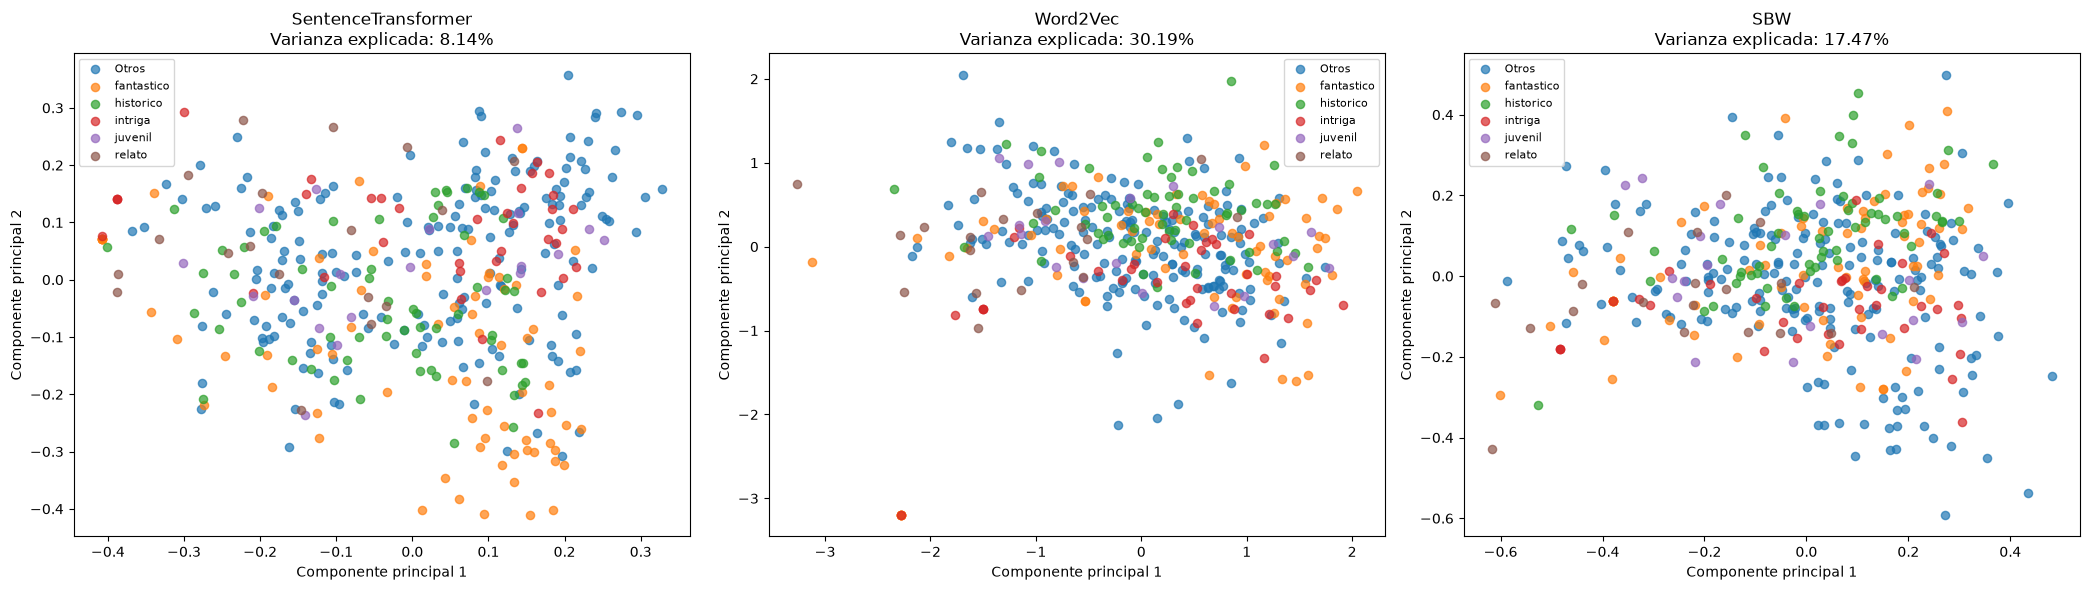

In [23]:
# Comparamos los tres modelos (SentenceTransformer, Word2Vec propio y SBW): vectores de documentos, rankings por consulta, distribución de similitudes y proyección PCA

# Carga de los libros; los géneros están guardados como texto y se convierten en listas
libros_comparacion = pd.read_csv(RUTA_CSV_LIMPIO)
# Géneros característicos: los generales, como "aventuras", están en casi todos los libros y no sirven para distinguirlos
generos_clave = list(terminos_por_genero(libros_comparacion))
libros_comparacion["generos"] = libros_comparacion["generos"].apply(ast.literal_eval)

# Carga de los modelos ya generados
modelo_w2v_comparacion = cargar_mejor_modelo()
modelo_sbw_comparacion = SBW_modelo()

# Con Word2Vec y SBW un documento se representa con el promedio de los vectores de sus palabras
def vector_documento(texto, modelo):
    palabras = str(texto).split()
    vectores = [
        modelo[word]
        for word in palabras
        if word in modelo.key_to_index
    ]

    if not vectores:
        return np.zeros(modelo.vector_size)

    return np.mean(vectores, axis=0)

# Representaciones de documentos de cada modelo
# SentenceTransformer codifica el texto original de cada sinopsis, sin limpiar
documentos = libros_comparacion["sinopsis"].fillna("").tolist()
documentos_crudos = pd.read_csv(RUTA_CSV_ORIGINAL, keep_default_na=False)["sinopsis"].tolist()

modelos_vectores = {
    "SentenceTransformer": modelo_sentence.encode(
        documentos_crudos,
        convert_to_numpy=True,
        show_progress_bar=False
    ),
    "Word2Vec": np.vstack([
        vector_documento(texto, modelo_w2v_comparacion.wv) for texto in documentos
    ]),
    "SBW": np.vstack([
        vector_documento(texto, modelo_sbw_comparacion) for texto in documentos
    ]),
}

# Cómo se vectoriza una consulta en cada modelo
# (Word2Vec y SBW la limpian igual que a las sinopsis antes de promediar)
codificadores = {
    "SentenceTransformer": lambda consulta: modelo_sentence.encode([consulta], convert_to_numpy=True),
    "Word2Vec": lambda consulta: vector_documento(
        limpiar_texto(consulta), modelo_w2v_comparacion.wv
    ).reshape(1, -1),
    "SBW": lambda consulta: vector_documento(
        limpiar_texto(consulta), modelo_sbw_comparacion
    ).reshape(1, -1),
}

def ranking_consulta(consulta, nombre_modelo, topn=5):
    # Similitud coseno entre la consulta y todos los libros
    puntuaciones = cosine_similarity(
        codificadores[nombre_modelo](consulta),
        modelos_vectores[nombre_modelo]
    )[0]

    # Nos quedamos con los topn libros más similares
    indices = np.argsort(puntuaciones)[::-1][:topn]

    return [
        (libros_comparacion.iloc[indice]["titulo"], float(puntuaciones[indice]))
        for indice in indices
    ]

# Consultas en lenguaje natural
consultas = [
    "una novela de aventuras y viajes peligrosos",
    "una historia de amor entre dos personajes",
    "una investigación relacionada con un misterio"
]

# Rankings lado a lado
for consulta in consultas:
    print(f"\nCONSULTA: {consulta}")

    rankings = {
        nombre: ranking_consulta(consulta, nombre)
        for nombre in modelos_vectores
    }

    tabla = PrettyTable()
    tabla.field_names = ["Posición"] + list(modelos_vectores)

    for posicion in range(5):
        fila = [posicion + 1]

        for nombre_modelo in modelos_vectores:
            titulo, similitud = rankings[nombre_modelo][posicion]
            fila.append(f"{titulo} ({similitud:.3f})")

        tabla.add_row(fila)

    print(tabla)

# Distribución de similitudes entre pares aleatorios de documentos
rng = np.random.default_rng(42)
cantidad_pares = min(5000, len(documentos) * (len(documentos) - 1) // 2)
pares_aleatorios = rng.integers(0, len(documentos), size=(cantidad_pares, 2))
pares_aleatorios = pares_aleatorios[pares_aleatorios[:, 0] != pares_aleatorios[:, 1]]

for nombre_modelo, vectores in modelos_vectores.items():
    similitudes = 1 - paired_cosine_distances(
        vectores[pares_aleatorios[:, 0]],
        vectores[pares_aleatorios[:, 1]]
    )

    print(f"\nDistribución de similitudes: {nombre_modelo}")
    print(f"Media: {similitudes.mean():.4f}")
    print(f"Desvío estándar: {similitudes.std():.4f}")
    print(f"Rango: [{similitudes.min():.4f}, {similitudes.max():.4f}]")

# Etiqueta de género para colorear: el primer género característico de cada libro
generos_grafico = libros_comparacion["generos"].apply(
    lambda lista: next((g for g in lista if g in generos_clave), "Otros")
)

# Proyección PCA
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (nombre_modelo, vectores) in zip(
    axes,
    modelos_vectores.items()
):
    pca = PCA(n_components=2, random_state=42)
    proyeccion = pca.fit_transform(vectores)

    varianza = pca.explained_variance_ratio_

    for genero in sorted(generos_grafico.unique()):
        mascara = (generos_grafico == genero).to_numpy()

        ax.scatter(
            proyeccion[mascara, 0],
            proyeccion[mascara, 1],
            label=genero,
            alpha=0.7,
            s=35
        )

    ax.set_title(
        f"{nombre_modelo}\n"
        f"Varianza explicada: "
        f"{varianza[0] + varianza[1]:.2%}"
    )
    ax.set_xlabel("Componente principal 1")
    ax.set_ylabel("Componente principal 2")
    ax.legend(fontsize=8)

    print(
        f"{nombre_modelo} - "
        f"PC1: {varianza[0]:.2%}, "
        f"PC2: {varianza[1]:.2%}, "
        f"total: {varianza.sum():.2%}"
    )

plt.tight_layout()
plt.show()